# IMU – Estabilidad en quietud (detección de temblor)

Este cuaderno analiza una prueba de estabilidad en quietud (todos los dispositivos en reposo). Dispositivos esperados: LEFT-HAND, RIGHT-HAND, LEFT-ANKLE, RIGHT-ANKLE y BASE-SPINE.

Qué hace este notebook:
- Carga el archivo JSON y aplana las señales por dispositivo.
- Estima la tasa de muestreo, calcula magnitudes y selecciona una ventana común de 10 s.
- Detecta temblor en la banda 3–8 Hz con criterios de potencia relativa y amplitud RMS, idénticos a los usados en la prueba de mano derecha tocar nariz.
- Genera gráficos en el tiempo y del espectro (PSD) por dispositivo y un resumen de conclusiones.

Ajustes rápidos:
- Edita `json_path` si deseas analizar otro archivo.
- `rest_device_hint` se usa sólo como anotación en las conclusiones; en esta prueba todos los dispositivos están en reposo.

In [ ]:
# Imports y utilidades (idénticas a cuaderno mano derecha)
from __future__ import annotations
import json
from typing import Dict, Tuple
import numpy as np
import pandas as pd

# Gráficos
try:
    import matplotlib.pyplot as plt
    plt.style.use("seaborn-v0_8")
    _USE_MPL = True
except Exception:
    _USE_MPL = False
    try:
        import plotly.graph_objects as go
    except Exception:
        go = None

# Señales: SciPy si existe; si no, alternativas con NumPy
try:
    import scipy.signal as sps
    _HAVE_SCIPY = True
except Exception:
    sps = None
    _HAVE_SCIPY = False

def np_welch(x: np.ndarray, fs: float, nperseg: int = 1024):
    x = np.asarray(x, dtype=float)
    if len(x) < 4:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0])
    nperseg = int(min(nperseg, len(x)))
    if nperseg < 8:
        nperseg = max(8, len(x)//2)
    step = max(1, nperseg//2)
    win = np.hanning(nperseg)
    segs = []
    for start in range(0, len(x)-nperseg+1, step):
        seg = x[start:start+nperseg] - np.mean(x[start:start+nperseg])
        segs.append(seg*win)
    if not segs:
        seg = x - np.mean(x)
        win = np.hanning(len(seg))
        segs = [seg*win]
        nperseg = len(seg)
    segs = np.stack(segs, axis=0)
    X = np.fft.rfft(segs, axis=1)
    Pxx = (np.abs(X)**2) / (np.sum(win**2) * fs)
    Pxx = np.mean(Pxx, axis=0)
    f = np.fft.rfftfreq(nperseg, d=1.0/fs)
    return f, Pxx

def welch_psd(x: np.ndarray, fs: float, nperseg: int = 1024):
    if _HAVE_SCIPY:
        f, Pxx = sps.welch(x, fs=fs, nperseg=min(nperseg, len(x)), detrend='constant', scaling='density')
        return f, Pxx
    return np_welch(x, fs, nperseg)

def simple_bandpass(x: np.ndarray, fs: float, low: float, high: float) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if len(x) < 8 or not np.isfinite(fs) or fs <= 0:
        return np.zeros_like(x)
    if _HAVE_SCIPY and high < fs/2:
        try:
            b, a = sps.butter(4, [low/(fs/2), high/(fs/2)], btype='bandpass')
            return sps.filtfilt(b, a, x, method='gust')
        except Exception:
            pass
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1.0/fs)
    mask = (f >= low) & (f <= high)
    Xf = np.zeros_like(X)
    Xf[mask] = X[mask]
    return np.fft.irfft(Xf, n=len(x))

def trapz_power(f: np.ndarray, Pxx: np.ndarray) -> float:
    if f.size < 2 or Pxx.size < 2:
        return 0.0
    return float(np.trapz(Pxx, f))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Carga de JSON y aplanado (robusto ante estructuras distintas)
from pathlib import Path
from collections.abc import Mapping, Sequence

# Archivo por defecto para esta prueba de estabilidad en quietud
json_path = r"/content/drive/MyDrive/Trabajo de grado/Cuadernos Colab/Datos/Paciente Sano/3.17-Control.json"
assert Path(json_path).exists(), f"No se encontró el archivo: {json_path}"

def _to_number(v):
    try:
        return float(v)
    except Exception:
        return np.nan

def _extract_imu_records(obj, out_list):
    # Recorre recursivamente para encontrar dicts con acelerómetro/giroscopio y timestamp+deviceId
    if isinstance(obj, Mapping):
        # Si el valor es string que parece JSON, intenta parsearlo
        for k, v in list(obj.items()):
            if isinstance(v, str) and v and v.strip().startswith(('{','[')):
                try:
                    obj[k] = json.loads(v)
                except Exception:
                    pass
        acc = obj.get('accelerometer')
        gyr = obj.get('gyroscope')
        dev = obj.get('deviceId') or obj.get('device') or obj.get('placement') or obj.get('name')
        ts  = obj.get('timestamp') or obj.get('time') or obj.get('ts')
        if (isinstance(acc, Mapping) or isinstance(gyr, Mapping)) and (dev is not None) and (ts is not None):
            out_list.append({
                'deviceId': str(dev),
                'timestamp_ms': _to_number(ts),
                'ax': _to_number((acc or {}).get('x', np.nan)),
                'ay': _to_number((acc or {}).get('y', np.nan)),
                'az': _to_number((acc or {}).get('z', np.nan)),
                'gx': _to_number((gyr or {}).get('x', np.nan)),
                'gy': _to_number((gyr or {}).get('y', np.nan)),
                'gz': _to_number((gyr or {}).get('z', np.nan)),
            })
        # Recurse
        for v in obj.values():
            _extract_imu_records(v, out_list)
    elif isinstance(obj, Sequence) and not isinstance(obj, (str, bytes, bytearray)):
        for it in obj:
            _extract_imu_records(it, out_list)

with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

patient = (data.get('patient', {}) if isinstance(data, Mapping) else {})
test_type = (data.get('testType', None) if isinstance(data, Mapping) else None)
imu_data = (data.get('imuData', []) if isinstance(data, Mapping) else [])

# Si imuData viene como string JSON, parsearlo
if isinstance(imu_data, str) and imu_data.strip().startswith(('{','[')):
    try:
        imu_data = json.loads(imu_data)
    except Exception:
        imu_data = []

rows = []
# Ruta estándar si hay imuData en lista
if isinstance(imu_data, list) and imu_data:
    for p in imu_data:
        acc = (p.get('accelerometer', {}) if isinstance(p, Mapping) else {}) or {}
        gyr = (p.get('gyroscope', {}) if isinstance(p, Mapping) else {}) or {}
        rows.append({
            'deviceId': (p.get('deviceId') if isinstance(p, Mapping) else 'UNKNOWN') or 'UNKNOWN',
            'timestamp_ms': _to_number(p.get('timestamp') if isinstance(p, Mapping) else np.nan),
            'ax': _to_number(acc.get('x', np.nan)), 'ay': _to_number(acc.get('y', np.nan)), 'az': _to_number(acc.get('z', np.nan)),
            'gx': _to_number(gyr.get('x', np.nan)), 'gy': _to_number(gyr.get('y', np.nan)), 'gz': _to_number(gyr.get('z', np.nan)),
        })
else:
    # Extracción recursiva en toda la estructura
    _extract_imu_records(data, rows)

print(f"Registros IMU (contados): {len(rows)} | TestType: {test_type}")
print("Paciente:", patient)

# Construir DataFrame con columnas garantizadas (aunque rows esté vacío)
columns = ['deviceId','timestamp_ms','ax','ay','az','gx','gy','gz']
df = pd.DataFrame(rows, columns=columns)

# Si no hay filas, informar claramente
if df.empty:
    display(pd.DataFrame({'mensaje': [
        'No se encontraron registros IMU en el JSON.'],
        'pistas': [
        'Verifica que el archivo corresponde a la prueba y que contiene acelerometer/gyroscope.']}))
    raise AssertionError("El DataFrame de señales está vacío (estructura distinta a la esperada)")

# Limpieza y orden
keep_cols = ['deviceId','timestamp_ms','ax','ay','az','gx','gy','gz']
df = df.dropna(subset=['timestamp_ms','deviceId'])[keep_cols].sort_values(['deviceId','timestamp_ms']).reset_index(drop=True)
df.head()

Registros IMU (contados): 4361 | TestType: DYNAMIC_GAIT_INDEX
Paciente: {'birthDate': '23/10/2025', 'id': '16751329', 'name': 'Luis Felipe Jojoa Lasso', 'observations': 'Prueba Jojoa Estabilidad en estado de quietud\n\nnota: Se encuentra en estado ON en todas las pruebas realizadas hasta hoy 16 de octubre \n\nmedicamento: Carbidopa Levodopa pastilla 25 MG / 250 MG es un compuesto de 2 medicamentos en una pastilla concentración de el en específico \n'}


,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz
0,BASE-SPINE,808110.0,1.006958,-0.103882,-0.143433,0.915527,-1.953125,-0.244141
1,BASE-SPINE,808137.0,1.003174,-0.105835,-0.142822,0.183105,-2.624512,-0.366211
2,BASE-SPINE,808163.0,1.005737,-0.107422,-0.145630,0.671387,-2.685547,-0.427246
3,BASE-SPINE,808190.0,1.006714,-0.105835,-0.151367,0.366211,-2.136230,-0.488281
4,BASE-SPINE,808216.0,1.002075,-0.103516,-0.147705,0.183105,-1.464844,-0.366211


In [ ]:
# Preprocesamiento y ventana de 10 s
def estimate_fs_ms(t_ms: np.ndarray) -> float:
    t_ms = np.asarray(t_ms, dtype=float)
    if t_ms.size < 2:
        return float('nan')
    dt = np.diff(t_ms)/1000.0
    dt = dt[dt > 0]
    if dt.size == 0:
        return float('nan')
    med = np.median(dt)
    return float('inf') if med <= 0 else 1.0/med

df = df.copy()
df['t'] = df.groupby('deviceId')['timestamp_ms'].transform(lambda x: (x - x.iloc[0]) / 1000.0)
df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

devices = list(df['deviceId'].dropna().unique())
fs_map: Dict[str, float] = {d: estimate_fs_ms(df.loc[df['deviceId']==d, 'timestamp_ms'].to_numpy()) for d in devices}
fs_map

# Ventana común de 10 s centrada si es posible
per_dev_max = df.groupby('deviceId')['t'].max()
per_dev_min = df.groupby('deviceId')['t'].min()
global_min = float(per_dev_min.max()) if not per_dev_min.empty else 0.0
global_max = float(per_dev_max.min()) if not per_dev_max.empty else 0.0
dur = max(0.0, global_max - global_min)
if dur >= 10.0:
    start_t = global_min + (dur - 10.0)/2.0
    end_t = start_t + 10.0
else:
    start_t = global_min
    end_t = global_max
print(f"Ventana seleccionada: [{start_t:.2f}, {end_t:.2f}] s (dur={end_t-start_t:.2f}s)")

mask = (df['t'] >= start_t) & (df['t'] <= end_t)
df_win = df.loc[mask].copy()
assert not df_win.empty, "No hay datos en la ventana seleccionada"
df_win.head()

Ventana seleccionada: [7.94, 17.94] s (dur=10.00s)


,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz,t,acc_mag,gyro_mag
303,BASE-SPINE,816078.0,1.004639,-0.105957,-0.136719,0.793457,0.305176,-0.305176,7.968,1.019421,0.903238
304,BASE-SPINE,816104.0,1.006348,-0.103516,-0.141968,-0.122070,1.159668,-0.244141,7.994,1.021571,1.191359
305,BASE-SPINE,816130.0,1.004395,-0.105591,-0.134399,0.061035,0.732422,-0.305176,8.020,1.018834,0.795801
306,BASE-SPINE,816157.0,1.005737,-0.107910,-0.137817,0.305176,0.427246,-0.366211,8.047,1.020855,0.640142
307,BASE-SPINE,816183.0,1.006226,-0.107056,-0.134033,0.366211,0.671387,-0.488281,8.073,1.020743,0.907353


In [ ]:
# Detección de temblor (idéntica a mano derecha)
from dataclasses import dataclass
from typing import Tuple

@dataclass
class TremorResult:
    device: str
    signal: str
    fs: float
    peak_freq_hz: float
    band_power: float
    total_power: float
    ratio: float
    rms_tremor: float
    band: Tuple[float, float]
    is_tremor: bool

def detect_tremor(sig: np.ndarray, fs: float, band: Tuple[float,float]=(3.0,8.0), broad: Tuple[float,float]=(0.5,15.0), rms_threshold: float=0.02):
    if not np.isfinite(fs) or fs <= 0 or sig.size < max(64, int(fs*2)):
        return (float('nan'), 0.0, 0.0, 0.0, False)
    x = np.asarray(sig, dtype=float) - np.mean(sig)
    f, Pxx = welch_psd(x, fs=fs, nperseg=min(1024, max(128, int(fs*2))))
    if f.size < 4:
        return (float('nan'), 0.0, 0.0, 0.0, False)
    bmask = (f >= band[0]) & (f <= band[1])
    amask = (f >= broad[0]) & (f <= broad[1])
    if not np.any(bmask) or not np.any(amask):
        return (float('nan'), 0.0, 0.0, 0.0, False)
    band_power = trapz_power(f[bmask], Pxx[bmask])
    total_power = trapz_power(f[amask], Pxx[amask])
    ratio = (band_power/total_power) if total_power > 0 else 0.0
    try:
        idx = int(np.argmax(Pxx[bmask]))
        peak_freq = float(f[bmask][idx])
    except Exception:
        peak_freq = float('nan')
    y = simple_bandpass(x, fs, 3, 8)
    rms = float(np.sqrt(np.mean(y*y))) if y.size else 0.0
    is_tremor = (ratio >= 0.3) and (rms >= rms_threshold)
    return (peak_freq, band_power, total_power, ratio, is_tremor)

In [ ]:
# Ejecutar detección por dispositivo (acc y gyro). Todos en reposo (control)
rest_device_hint = 'BASE-SPINE'  # en esta prueba todos en reposo; usamos columna para anotación
results = []
for dev in devices:
    sub = df_win[df_win['deviceId']==dev]
    if sub.empty:
        continue
    fs = fs_map.get(dev, float('nan'))
    acc = sub['acc_mag'].to_numpy()
    gyro = sub['gyro_mag'].to_numpy()
    # Acelerómetro (g)
    pk, bp, tp, r, flag = detect_tremor(acc, fs, band=(3,8), broad=(0.5,15), rms_threshold=0.02)
    results.append(TremorResult(dev, 'acc_mag', float(fs), float(pk), float(bp), float(tp), float(r), float(np.sqrt(np.mean(simple_bandpass(acc, fs, 3, 8)**2))) if np.isfinite(fs) and fs>0 else 0.0, (3.0, 8.0), bool(flag)))
    # Giróscopo (deg/s)
    pk, bp, tp, r, flag = detect_tremor(gyro, fs, band=(3,8), broad=(0.5,15), rms_threshold=0.5)
    results.append(TremorResult(dev, 'gyro_mag', float(fs), float(pk), float(bp), float(tp), float(r), float(np.sqrt(np.mean(simple_bandpass(gyro, fs, 3, 8)**2))) if np.isfinite(fs) and fs>0 else 0.0, (3.0, 8.0), bool(flag)))

summary = pd.DataFrame([r.__dict__ for r in results])
summary

/tmp/ipython-input-4129338187.py:79: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx, f))


,device,signal,fs,peak_freq_hz,band_power,total_power,ratio,rms_tremor,band,is_tremor
0,BASE-SPINE,acc_mag,38.461538,4.807692,3.169918e-06,5.906687e-06,0.536666,0.031759,"(3.0, 8.0)",False
1,BASE-SPINE,gyro_mag,38.461538,3.605769,5.749229e-02,2.488241e-01,0.231056,0.231305,"(3.0, 8.0)",False
2,LEFT-ANKLE,acc_mag,38.461538,7.812500,1.668752e-07,7.776242e-07,0.214596,0.034390,"(3.0, 8.0)",False
3,LEFT-ANKLE,gyro_mag,38.461538,4.807692,1.572742e-03,3.832165e-03,0.410406,0.414261,"(3.0, 8.0)",False
4,LEFT-HAND,acc_mag,38.461538,5.709135,5.302945e-07,1.757336e-06,0.301761,0.034225,"(3.0, 8.0)",False
5,LEFT-HAND,gyro_mag,38.461538,5.709135,1.261565e-02,2.939183e-02,0.429223,0.102829,"(3.0, 8.0)",False
6,RIGHT-ANKLE,acc_mag,37.037037,7.233796,3.410162e-07,2.333724e-06,0.146125,0.033867,"(3.0, 8.0)",False
7,RIGHT-ANKLE,gyro_mag,37.037037,7.812500,1.772765e-03,5.573380e-03,0.318077,0.045283,"(3.0, 8.0)",False
8,RIGHT-HAND,acc_mag,38.461538,6.310096,6.221122e-07,1.848676e-06,0.336518,0.037293,"(3.0, 8.0)",False
9,RIGHT-HAND,gyro_mag,38.461538,6.310096,3.540342e-02,1.079914e-01,0.327836,0.475690,"(3.0, 8.0)",False


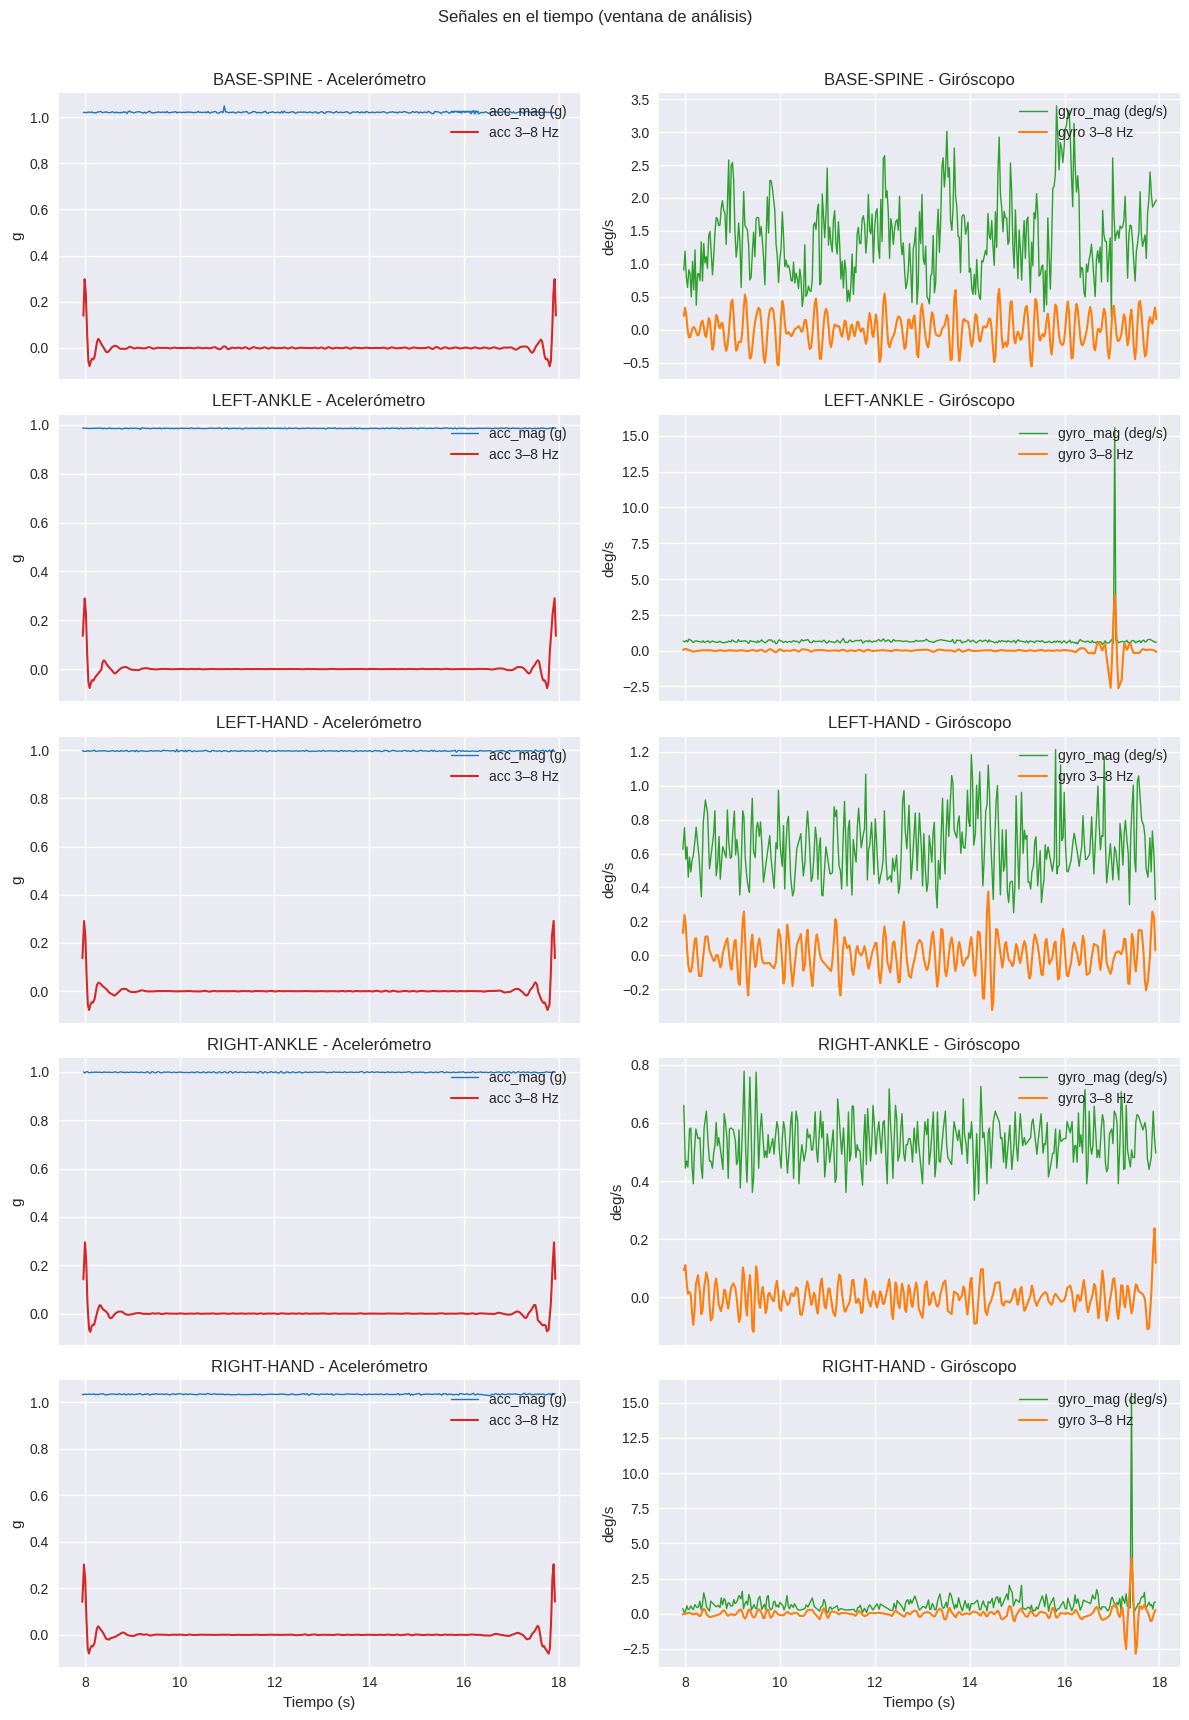

In [ ]:
# Gráficos de tiempo con componente 3–8 Hz
if _USE_MPL:
    n = len(devices) if devices else 1
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 3.5*n), sharex=True)
    if n == 1:
        axes = np.array([axes])
    for i, dev in enumerate(devices):
        sub = df_win[df_win['deviceId']==dev]
        t = sub['t'].to_numpy()
        acc = sub['acc_mag'].to_numpy()
        gyro = sub['gyro_mag'].to_numpy()
        fs = fs_map.get(dev, float('nan'))
        acc_trem = simple_bandpass(acc, fs, 3, 8) if np.isfinite(fs) and fs>0 else np.zeros_like(acc)
        gyro_trem = simple_bandpass(gyro, fs, 3, 8) if np.isfinite(fs) and fs>0 else np.zeros_like(gyro)
        ax0 = axes[i,0]
        ax0.plot(t, acc, color='#1f77b4', label='acc_mag (g)', linewidth=1)
        ax0.plot(t, acc_trem, color='#d62728', label='acc 3–8 Hz', linewidth=1.5)
        ax0.set_title(f"{dev} - Acelerómetro")
        ax0.set_ylabel('g')
        ax0.legend(loc='upper right')
        ax1 = axes[i,1]
        ax1.plot(t, gyro, color='#2ca02c', label='gyro_mag (deg/s)', linewidth=1)
        ax1.plot(t, gyro_trem, color='#ff7f0e', label='gyro 3–8 Hz', linewidth=1.5)
        ax1.set_title(f"{dev} - Giróscopo")
        ax1.set_ylabel('deg/s')
        ax1.legend(loc='upper right')
    for j in range(2):
        axes[-1,j].set_xlabel('Tiempo (s)')
    fig.suptitle('Señales en el tiempo (ventana de análisis)')
    fig.tight_layout(rect=[0,0,1,0.97])
    plt.show()
elif go is not None:
    for dev in devices:
        sub = df_win[df_win['deviceId']==dev]
        t = sub['t'].to_numpy()
        fs = fs_map.get(dev, float('nan'))
        acc = sub['acc_mag'].to_numpy()
        acc_trem = simple_bandpass(acc, fs, 3, 8) if np.isfinite(fs) and fs>0 else np.zeros_like(acc)
        fig1 = go.Figure()
        fig1.add_scatter(x=t, y=acc, name='acc_mag (g)')
        fig1.add_scatter(x=t, y=acc_trem, name='acc 3–8 Hz')
        fig1.update_layout(title=f'{dev} - Acelerómetro (ventana)', xaxis_title='Tiempo (s)', yaxis_title='g')
        fig1.show()
        gyro = sub['gyro_mag'].to_numpy()
        gyro_trem = simple_bandpass(gyro, fs, 3, 8) if np.isfinite(fs) and fs>0 else np.zeros_like(gyro)
        fig2 = go.Figure()
        fig2.add_scatter(x=t, y=gyro, name='gyro_mag (deg/s)')
        fig2.add_scatter(x=t, y=gyro_trem, name='gyro 3–8 Hz')
        fig2.update_layout(title=f'{dev} - Giróscopo (ventana)', xaxis_title='Tiempo (s)', yaxis_title='deg/s')
        fig2.show()
else:
    print('No hay backend de gráficos disponible.')

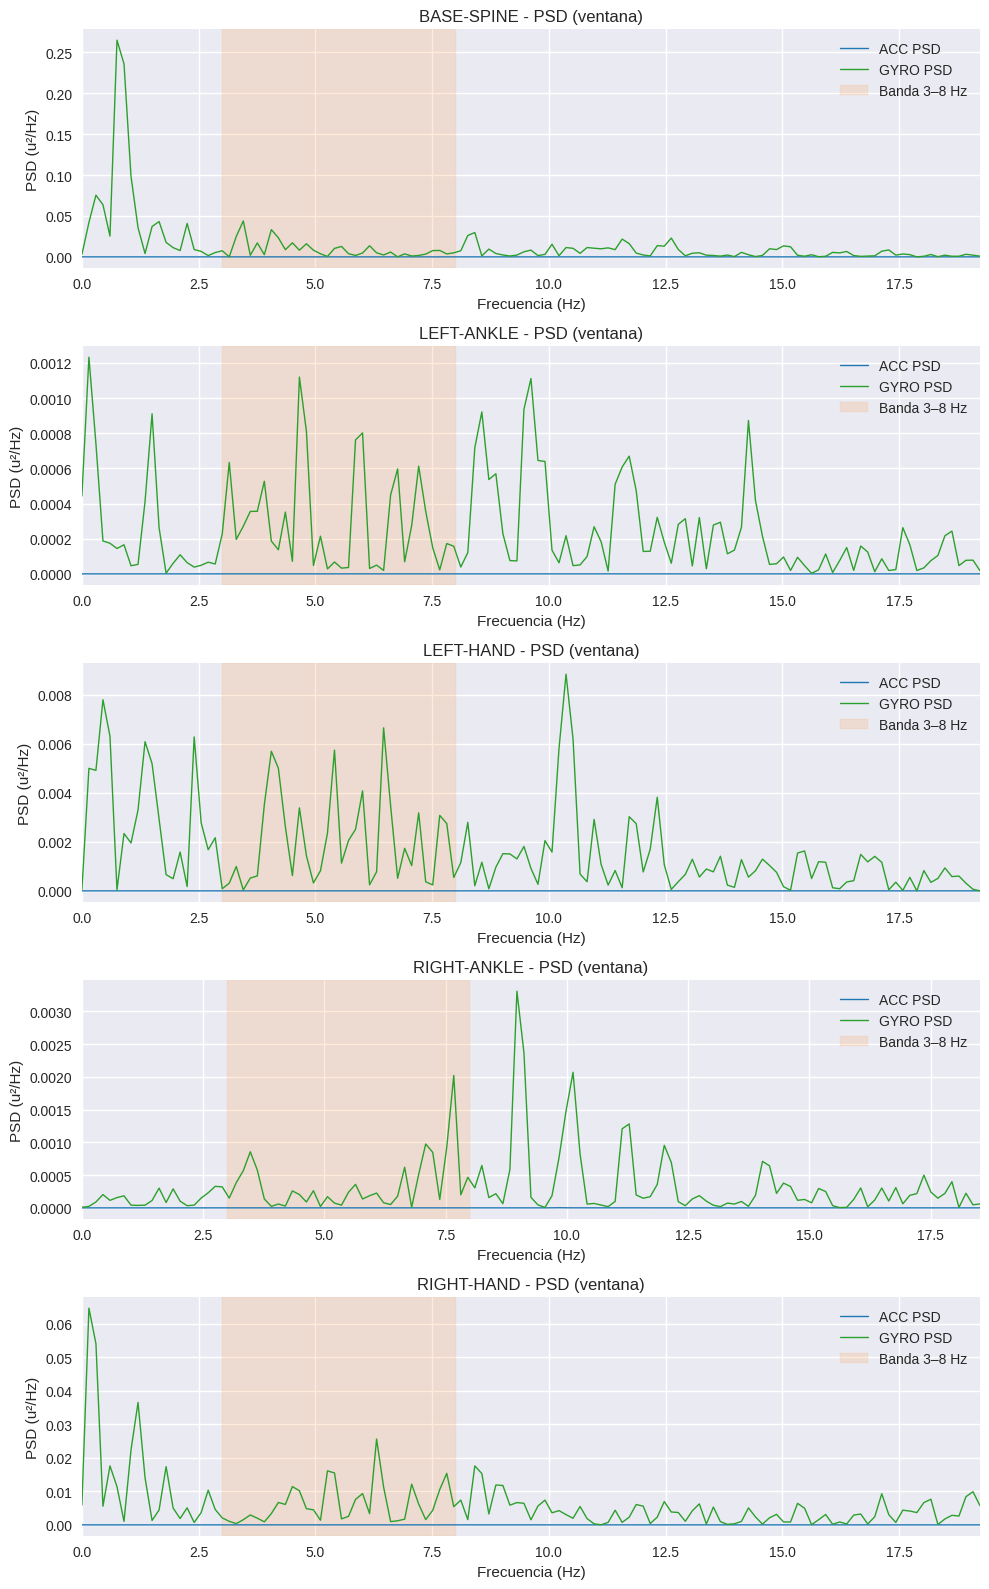

In [ ]:
# PSD por dispositivo con banda 3–8 Hz (ejes seguros)
if _USE_MPL:
    n = len(devices) if devices else 1
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, 3.2*n), sharex=False)
    axes = np.atleast_1d(axes).ravel()
    for i, dev in enumerate(devices):
        sub = df_win[df_win['deviceId']==dev]
        fs = fs_map.get(dev, float('nan'))
        acc = sub['acc_mag'].to_numpy() - np.mean(sub['acc_mag'].to_numpy())
        gyro = sub['gyro_mag'].to_numpy() - np.mean(sub['gyro_mag'].to_numpy())
        f_acc, P_acc = welch_psd(acc, fs=fs, nperseg=min(2048, max(256, len(acc)//2)))
        f_gyro, P_gyro = welch_psd(gyro, fs=fs, nperseg=min(2048, max(256, len(gyro)//2)))
        ax = axes[i]
        ax.plot(f_acc, P_acc, color='#1f77b4', lw=1, label='ACC PSD')
        ax.plot(f_gyro, P_gyro, color='#2ca02c', lw=1, label='GYRO PSD')
        ax.axvspan(3.0, 8.0, color='#ff7f0e', alpha=0.15, label='Banda 3–8 Hz')
        # marcar pico si se detectó
        det = [r for r in results if r.device==dev and r.is_tremor]
        if det:
            rbest = sorted(det, key=lambda r: r.ratio, reverse=True)[0]
            if np.isfinite(rbest.peak_freq_hz):
                ax.axvline(rbest.peak_freq_hz, color='#d62728', linestyle='--', alpha=0.7)
                ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1.0
                ax.text(rbest.peak_freq_hz, ymax*0.8, f"{rbest.peak_freq_hz:.2f} Hz", color='#d62728')
        ax.set_xlim(0, min(20, (fs or 20)/2))
        ax.set_xlabel('Frecuencia (Hz)')
        ax.set_ylabel('PSD (u²/Hz)')
        ax.set_title(f'{dev} - PSD (ventana)')
        ax.legend(loc='upper right')
    fig.tight_layout()
    plt.show()
elif go is not None:
    for dev in devices:
        sub = df_win[df_win['deviceId']==dev]
        fs = fs_map.get(dev, float('nan'))
        acc = sub['acc_mag'].to_numpy() - np.mean(sub['acc_mag'].to_numpy())
        gyro = sub['gyro_mag'].to_numpy() - np.mean(sub['gyro_mag'].to_numpy())
        f_acc, P_acc = welch_psd(acc, fs=fs, nperseg=min(2048, max(256, len(acc)//2)))
        f_gyro, P_gyro = welch_psd(gyro, fs=fs, nperseg=min(2048, max(256, len(gyro)//2)))
        fig = go.Figure()
        fig.add_scatter(x=f_acc, y=P_acc, name='ACC PSD')
        fig.add_scatter(x=f_gyro, y=P_gyro, name='GYRO PSD')
        fig.update_layout(title=f'{dev} - PSD', xaxis_title='Frecuencia (Hz)', yaxis_title='PSD (u²/Hz)')
        fig.show()
else:
    print('No hay backend de gráficos disponible.')

## Interpretación para esta tarea

- Todos los dispositivos están en reposo; el detector se enfoca en 3–8 Hz. Energía relevante en esta banda indica temblor en reposo.
- Las manos (LEFT-HAND, RIGHT-HAND) deberían mostrar potencias bajas si no hay temblor en reposo visible.
- Los tobillos (LEFT-ANKLE, RIGHT-ANKLE) pueden transmitir vibración, pero típicamente menor que en manos si el temblor es periférico.
- BASE-SPINE ayuda a detectar artefactos globales; energía 3–8 Hz notable aquí sugiere origen central/artefacto.

In [ ]:
# Resumen y conclusiones (regla de fusión configurable + control en reposo)
def pretty_bool(b):
    return 'SÍ' if bool(b) else 'NO'

# Regla de fusión: 'gyro' | 'acc' | 'either' | 'both'
fusion_rule = 'gyro'  # por defecto decidimos por giroscopio
rest_device_hint = rest_device_hint  # definido arriba en detección

if 'summary' in globals() and isinstance(summary, pd.DataFrame) and not summary.empty:
    display(summary[['device','signal','fs','peak_freq_hz','ratio','rms_tremor','is_tremor']].round(4))
    print('\nConclusiones por dispositivo (regla =', fusion_rule, ', control en reposo =', rest_device_hint, '):')
    for dev in devices:
        gyro_row = summary[(summary['device']==dev) & (summary['signal']=='gyro_mag')]
        acc_row  = summary[(summary['device']==dev) & (summary['signal']=='acc_mag')]
        gflag = bool(gyro_row['is_tremor'].iloc[0]) if not gyro_row.empty else False
        aflag = bool(acc_row['is_tremor'].iloc[0]) if not acc_row.empty else False
        pf_g  = float(gyro_row['peak_freq_hz'].iloc[0]) if not gyro_row.empty else float('nan')
        pf_a  = float(acc_row['peak_freq_hz'].iloc[0]) if not acc_row.empty else float('nan')
        if fusion_rule == 'gyro':
            final_flag = gflag
        elif fusion_rule == 'acc':
            final_flag = aflag
        elif fusion_rule == 'either':
            final_flag = gflag or aflag
        elif fusion_rule == 'both':
            final_flag = gflag and aflag
        else:
            final_flag = gflag
        ctx = ' (reposo)'
        if final_flag:
            if gflag and not aflag:
                note = 'Temblor detectado principalmente en GIROSCOPIO; amplitud lineal baja (típico en temblor leve).'+ctx
            elif aflag and not gflag:
                note = 'Temblor detectado en ACELERÓMETRO; revisar ruido/artefactos en gyro.'+ctx
            else:
                note = 'Temblor detectado en ambos canales.'+ctx
        else:
            note = 'No detectado según criterios actuales.'+ctx
        print(f" - {dev}: Temblor={pretty_bool(final_flag)} | gyro={pretty_bool(gflag)} (f={pf_g:.2f}Hz) | acc={pretty_bool(aflag)} (f={pf_a:.2f}Hz) -> {note}")
else:
    print('No hay resultados para mostrar.')

,device,signal,fs,peak_freq_hz,ratio,rms_tremor,is_tremor
0,BASE-SPINE,acc_mag,38.4615,4.8077,0.5367,0.0318,False
1,BASE-SPINE,gyro_mag,38.4615,3.6058,0.2311,0.2313,False
2,LEFT-ANKLE,acc_mag,38.4615,7.8125,0.2146,0.0344,False
3,LEFT-ANKLE,gyro_mag,38.4615,4.8077,0.4104,0.4143,False
4,LEFT-HAND,acc_mag,38.4615,5.7091,0.3018,0.0342,False
5,LEFT-HAND,gyro_mag,38.4615,5.7091,0.4292,0.1028,False
6,RIGHT-ANKLE,acc_mag,37.0370,7.2338,0.1461,0.0339,False
7,RIGHT-ANKLE,gyro_mag,37.0370,7.8125,0.3181,0.0453,False
8,RIGHT-HAND,acc_mag,38.4615,6.3101,0.3365,0.0373,False
9,RIGHT-HAND,gyro_mag,38.4615,6.3101,0.3278,0.4757,False



Conclusiones por dispositivo (regla = gyro , control en reposo = BASE-SPINE ):
 - BASE-SPINE: Temblor=NO | gyro=NO (f=3.61Hz) | acc=NO (f=4.81Hz) -> No detectado según criterios actuales. (reposo)
 - LEFT-ANKLE: Temblor=NO | gyro=NO (f=4.81Hz) | acc=NO (f=7.81Hz) -> No detectado según criterios actuales. (reposo)
 - LEFT-HAND: Temblor=NO | gyro=NO (f=5.71Hz) | acc=NO (f=5.71Hz) -> No detectado según criterios actuales. (reposo)
 - RIGHT-ANKLE: Temblor=NO | gyro=NO (f=7.81Hz) | acc=NO (f=7.23Hz) -> No detectado según criterios actuales. (reposo)
 - RIGHT-HAND: Temblor=NO | gyro=NO (f=6.31Hz) | acc=NO (f=6.31Hz) -> No detectado según criterios actuales. (reposo)


In [ ]:
# ============================================================================
# CÁLCULO DE SCORE MDS-UPDRS 3.17 (Temblor de Reposo / CONTROL)
# ============================================================================
# Score 0: Normal (sin temblor)
# Score 1: Leve (temblor detectado, gyro_rms < 1.0 deg/s)
# Score 2: Moderado-leve (1.0 ≤ gyro_rms < 3.0 deg/s)
# Score 3: Moderado (3.0 ≤ gyro_rms < 8.0 deg/s)
# Score 4: Severo (gyro_rms ≥ 8.0 deg/s)

def calculate_mds_updrs_score(gyro_rms: float, tremor_detected: bool) -> tuple:
    """Calcula score MDS-UPDRS (0-4) y etiqueta descriptiva."""
    if not tremor_detected:
        return (0, "Normal")
    if gyro_rms < 1.0:
        return (1, "Leve")
    elif gyro_rms < 3.0:
        return (2, "Moderado-leve")
    elif gyro_rms < 8.0:
        return (3, "Moderado")
    else:
        return (4, "Severo")

# Procesar scores por dispositivo
if 'summary' in globals() and isinstance(summary, pd.DataFrame) and not summary.empty:
    scores_by_device = {}
    
    for dev in summary['device'].unique():
        dev_data = summary[summary['device'] == dev]
        gyro_data = dev_data[dev_data['signal'] == 'gyro_mag']
        
        if not gyro_data.empty:
            gyro_rms = gyro_data['rms_tremor'].iloc[0]
            tremor_detected = gyro_data['is_tremor'].iloc[0]
            score, label = calculate_mds_updrs_score(gyro_rms, tremor_detected)
            scores_by_device[dev] = {'score': score, 'label': label, 'gyro_rms': gyro_rms}
    
    # Score máximo entre todos los dispositivos (manos y tobillos)
    max_score = max([s['score'] for s in scores_by_device.values()]) if scores_by_device else 0
    max_devices = [dev for dev, data in scores_by_device.items() if data['score'] == max_score]
    
    # Dashboard visual
    if _USE_MPL:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        # Gráfico 1: Scores por dispositivo
        devices = list(scores_by_device.keys())
        scores = [scores_by_device[d]['score'] for d in devices]
        colors = ['green' if s == 0 else 'yellow' if s in [1, 2] else 'orange' if s == 3 else 'red' for s in scores]
        
        bars = ax1.bar(devices, scores, color=colors, edgecolor='black', linewidth=1.5)
        ax1.set_ylabel('Score MDS-UPDRS', fontsize=11, fontweight='bold')
        ax1.set_ylim(0, 4.5)
        ax1.set_title('Score MDS-UPDRS por Dispositivo (3.17 - Reposo / CONTROL)', fontweight='bold')
        ax1.axhline(y=0, color='k', linewidth=0.5)
        for i, (dev, score) in enumerate(zip(devices, scores)):
            label = scores_by_device[dev]['label']
            marker = '*' if dev in max_devices else ''
            ax1.text(i, score + 0.1, f"{score}\n{label}\n{marker}", ha='center', fontsize=9, fontweight='bold')
        
        # Gráfico 2: Resumen global
        ax2.axis('off')
        summary_text = f"""
        RESUMEN MDS-UPDRS 3.17 (REPOSO - CONTROL)
        ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        
        Score Máximo: {max_score}
        ({['Normal', 'Leve', 'Moderado-leve', 'Moderado', 'Severo'][max_score]})
        
        Dispositivos con máximo: {', '.join(max_devices) if max_devices else 'Ninguno'}
        
        Detalles por extremidad:
        """
        for dev, data in sorted(scores_by_device.items()):
            marker = '(*) ' if dev in max_devices else '    '
            summary_text += f"\n  {marker}{dev}: Score {data['score']}"
            summary_text += f"\n      {data['label']} | RMS: {data['gyro_rms']:.3f} deg/s"
        
        ax2.text(0.05, 0.95, summary_text, transform=ax2.transAxes, fontsize=10,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*60)
        print("SCORES MDS-UPDRS 3.17 (REPOSO - CONTROL)")
        print("="*60)
        for dev, data in sorted(scores_by_device.items()):
            marker = '[MAX]' if dev in max_devices else '     '
            print(f"{dev:15} {marker} | Score: {data['score']} ({data['label']:15s}) | RMS: {data['gyro_rms']:.4f}")
        print(f"{'MÁXIMO':15}       | Score: {max_score}")
        print("="*60)
    else:
        print("\n" + "="*60)
        print("SCORES MDS-UPDRS 3.17 (REPOSO - CONTROL)")
        print("="*60)
        for dev, data in sorted(scores_by_device.items()):
            marker = '[MAX]' if dev in max_devices else '     '
            print(f"{dev:15} {marker} | Score: {data['score']} ({data['label']:15s}) | RMS: {data['gyro_rms']:.4f}")
        print(f"{'MÁXIMO':15}       | Score: {max_score}")
        print("="*60)
else:
    print("No hay datos de 'summary' disponibles. Ejecute las celdas anteriores primero.")